In [1]:
# inline plotting
%matplotlib inline

# allow live package editing
%load_ext autoreload
%autoreload 2

# Importing the OpenDSM library

Once the OpenDSM has been installed, it can be imported as shown below.

This tutorial requires OpenDSM version > 1.2.x. Verify the version you have installed.

We will load eemeter and drmeter modules separately

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import opendsm as odsm
from opendsm import (
    eemeter as em,
    drmeter as dm,
)

print(f"OpenDSM {odsm.__version__}")

OpenDSM 1.2.6


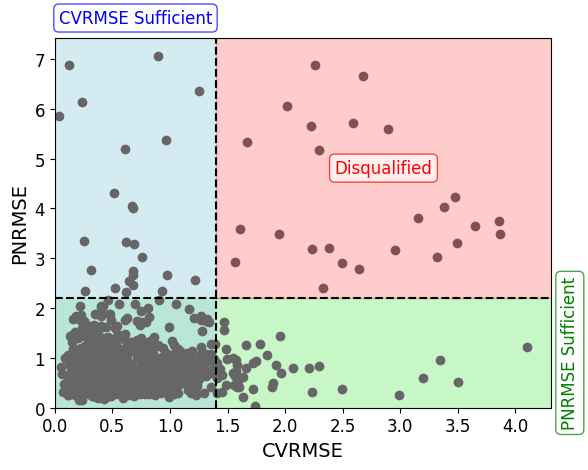

In [5]:
from scipy import stats

cvrmse = stats.lognorm.rvs(loc=0, s=0.6, size=950)
cvrmse = np.concatenate([cvrmse, stats.uniform(loc=0, scale=np.max(cvrmse)).rvs(size=50)])
pnrmse = stats.lognorm.rvs(loc=0, s=0.50, size=950)*1.4
pnrmse = np.concatenate([pnrmse, stats.uniform(loc=0, scale=np.max(pnrmse)).rvs(size=50)])

cvrmse *= 0.5
pnrmse *= 0.5

fig, ax = plt.subplots()
ax.axhspan(0, 2.2, color='lightgreen', alpha=0.5, zorder=0)
ax.axvspan(0, 1.4, color='lightblue', alpha=0.5, zorder=0)

ax.scatter(cvrmse, pnrmse, color=[0.4]*3)
ax.set_xlabel("CVRMSE")
ax.set_ylabel("PNRMSE")
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# Set tick marks font size to 12
ax.tick_params(axis='both', labelsize=12)

# set labels to be size 14
ax.set_xlabel("CVRMSE", fontsize=14)
ax.set_ylabel("PNRMSE", fontsize=14)

# Draw a red rectangle from (1.4, 2.2) to the upper right edge of the plot
xmax = ax.get_xlim()[1]
ymax = ax.get_ylim()[1]
ax.axvspan(1.4, xmax, ymin=2.2/ymax, ymax=1, color='red', edgecolor=None, alpha=0.2, zorder=1)

ax.axhline(2.2, color='black', linestyle='--', linewidth=1.5)
ax.axvline(1.4, color='black', linestyle='--', linewidth=1.5)

# Add "disqualified" text in the red box region
ax.text(
    1.4 + (xmax - 1.4) / 2,
    2.2 + (ymax - 2.2) / 2,
    "Disqualified",
    color='red',
    fontsize=12,
    # fontweight='bold',
    ha='center',
    va='center',
    rotation=0,
    bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.7)
)

# Add "PNRMSE Sufficient" text at 90 degrees on the right side, centered with the green box
green_box_ymin = 0
green_box_ymax = 2.2
y_center = (green_box_ymin + green_box_ymax) / 2
x_right = ax.get_xlim()[1]
ax.text(
    x_right + 0.02*(x_right),  # small offset to the right of the plot
    y_center,
    "PNRMSE Sufficient",
    color='green',
    fontsize=12,
    ha='left',
    va='center',
    rotation=90,
    bbox=dict(facecolor='white', edgecolor='green', boxstyle='round,pad=0.3', alpha=0.7)
)

# Add "CVRMSE Sufficient" text at the top of the plot above the blue box
blue_box_xmin = 0
blue_box_xmax = 1.4
x_center = (blue_box_xmin + blue_box_xmax) / 2
y_top = ax.get_ylim()[1]
ax.text(
    x_center,
    y_top + 0.03 * y_top,  # small offset above the plot
    "CVRMSE Sufficient",
    color='blue',
    fontsize=12,
    ha='center',
    va='bottom',
    rotation=0,
    bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.3', alpha=0.7)
)



plt.show()

# plt.hist(pnrmse, bins=30, edgecolor='black')
# plt.xlabel("CVRMSE")
# plt.ylabel("Frequency")
# plt.title("Histogram of CVRMSE")
# plt.show()
